In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Libraries:

In [11]:
import os
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# EDA:

[-0.00368009  0.00132239 -0.00500867 ...  0.00857612 -0.0098312
 -0.02689336]
22050


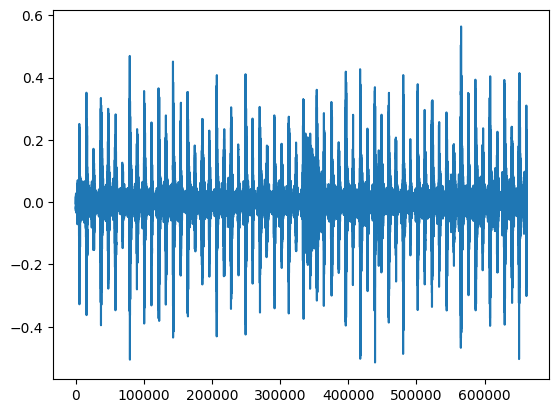

In [6]:
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

example_file = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/blues/blues.00000/drums.wav"

y, sr = librosa.load(example_file)
sns.lineplot(y)
print(y, sr, sep="\n")

In [8]:
y, sr = librosa.load(example_file, sr=None)
print("Sample rate:", sr)
print("Duration (sec):", len(y)/sr)

Sample rate: 44100
Duration (sec): 30.013333333333332


[-0.0039978   0.01495361  0.01623535 ...  0.01324463  0.07687378
  0.13162231]
22050


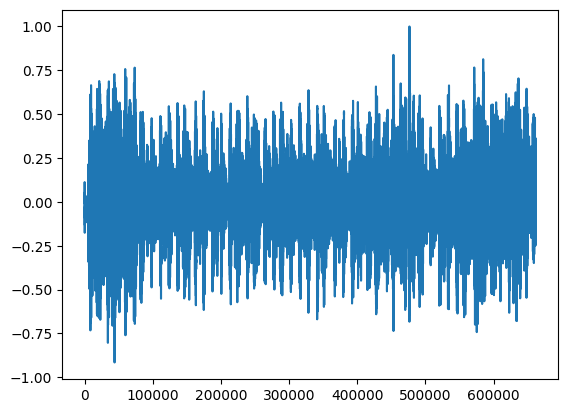

In [7]:
test_eg = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/mashups/song0001.wav"
y_t, sr_t = librosa.load(test_eg)
sns.lineplot(y_t)
print(y_t, sr_t, sep="\n")

In [9]:
y_t, sr_t = librosa.load(test_eg, sr=None)
print("Mashup sample rate:", sr_t)
print("Mashup duration:", len(y_t)/sr_t)

Mashup sample rate: 22050
Mashup duration: 30.00018140589569


In [12]:
# DATA_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"
# GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
# STEMS = ['bass.wav', 'drums.wav', 'other.wav', 'vocals.wav']

# train_srs = []
# train_durations = []
# train_silence = []
# train_rms = []

# for genre in tqdm(GENRES):
#     genre_path = os.path.join(DATA_PATH, genre)
    
#     for song in os.listdir(genre_path):
#         song_path = os.path.join(genre_path, song)

#         for stem in STEMS:
#             audio_path = os.path.join(song_path, stem)

#             y, sr = librosa.load(audio_path, sr=None)
#             duration = len(y) / sr
#             silence_ratio = np.mean(np.abs(y) < 1e-4)
#             rms = np.mean(librosa.feature.rms(y=y))
            
#             train_srs.append(sr)
#             train_durations.append(duration)
#             train_silence.append(silence_ratio)
#             train_rms.append(rms)

# print("Train unique SRs:", set(train_srs))
# print("Train duration mean:", np.mean(train_durations))
# print("Train duration std:", np.std(train_durations))
# print("Train silence mean:", np.mean(train_silence))
# print("Train RMS mean:", np.mean(train_rms))

# Train unique SRs: {44100}
# Train duration mean: 30.02404707482993
# Train duration std: 0.08087336094347475
# Train silence mean: 0.16854941092207973
# Train RMS mean: 0.04491053

100%|██████████| 10/10 [07:44<00:00, 46.48s/it]

Train unique SRs: {44100}
Train duration mean: 30.02404707482993
Train duration std: 0.08087336094347475
Train silence mean: 0.16854941092207973
Train RMS mean: 0.04491053


In [14]:
# mashup_path = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/mashups"

# test_srs = []
# test_durations = []
# test_silence = []
# test_rms = []

# for song in tqdm(os.listdir(mashup_path)):
#     audio_path = os.path.join(mashup_path, song)

#     y, sr = librosa.load(audio_path, sr=None)
    
#     duration = len(y) / sr
#     silence_ratio = np.mean(np.abs(y) < 1e-4)
#     rms = np.mean(librosa.feature.rms(y=y))
    
#     test_srs.append(sr)
#     test_durations.append(duration)
#     test_silence.append(silence_ratio)
#     test_rms.append(rms)

# print("Test unique SRs:", set(test_srs))
# print("Test duration mean:", np.mean(test_durations))
# print("Test duration std:", np.std(test_durations))
# print("Test silence mean:", np.mean(test_silence))
# print("Test RMS mean:", np.mean(test_rms))

# Test unique SRs: {22050}
# Test duration mean: 28.653239927317504
# Test duration std: 3.772994605159907
# Test silence mean: 0.0009087508105784579
# Test RMS mean: 0.12791249

100%|██████████| 3020/3020 [01:35<00:00, 31.72it/s]

Test unique SRs: {22050}
Test duration mean: 28.653239927317504
Test duration std: 3.772994605159907
Test silence mean: 0.0009087508105784579
Test RMS mean: 0.12791249
